In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path
from tabulate import tabulate
from great_tables import GT, md

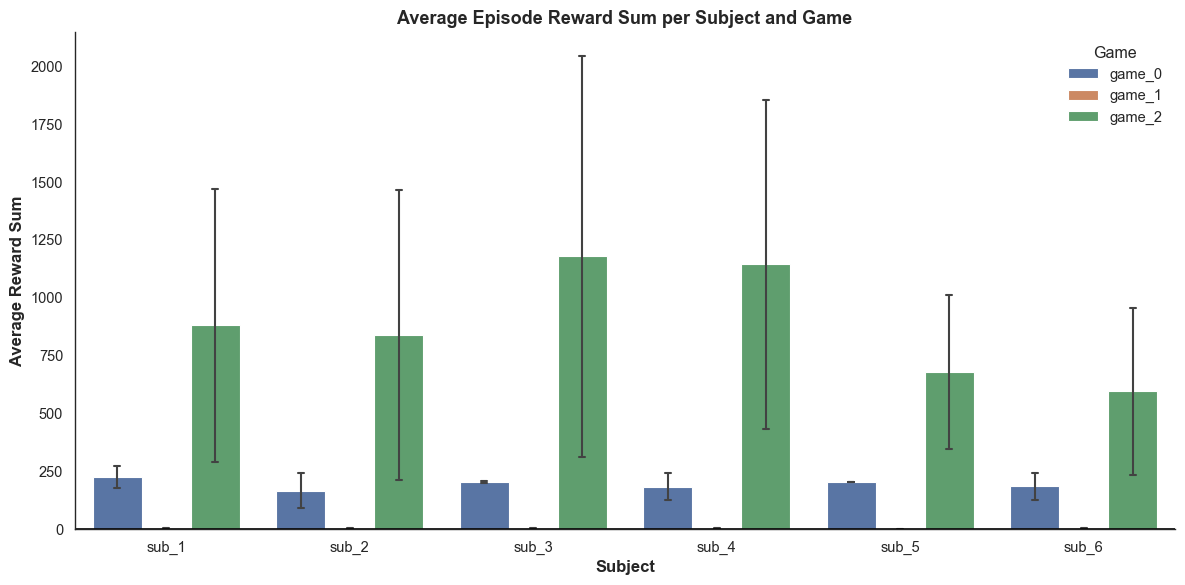

In [2]:
# base path 지정E:\behav\behavioral_data_4kframe_legacy
base_path = Path("E:/behav/behavioral_data_4kframe_legacy")

# reward sum 저장용 리스트
reward_records = []

# 전체 폴더 순회
for sub_dir in base_path.glob("sub_*"):
    sub_id = sub_dir.name  # 예: sub_1

    for game_dir in sub_dir.glob("game_*"):
        game_id = game_dir.name  # 예: game_0

        # 🔥 day, block 폴더를 포함한 하위 npz 파일까지 재귀적으로 찾는다
        for npz_file in game_dir.glob("**/*.npz"):
            try:
                data = np.load(npz_file)
                reward_sum = np.sum(data["reward"])
                reward_records.append({
                    "subject": sub_id,
                    "game": game_id,
                    "episode": npz_file.name,
                    "reward_sum": reward_sum
                })
            except Exception as e:
                print(f"Error loading {npz_file}: {e}")

# DataFrame 생성
df = pd.DataFrame(reward_records)
df_grouped = df.groupby(["subject", "game"])["reward_sum"].mean().reset_index()

# 시각화
sns.set(style="white", context="paper", font_scale=1.2)
plt.figure(figsize=(12, 6))
sns.barplot(
    data=df,
    x="subject",
    y="reward_sum",
    hue="game",
    errorbar="sd",
    err_kws={'linewidth': 1.5},
    capsize=0.1
)
plt.axhline(0, color="black", linewidth=1.2)
plt.ylim(bottom=0)
plt.xlabel("Subject", fontsize=12, fontweight='bold')
plt.ylabel("Average Reward Sum", fontsize=12, fontweight='bold')
plt.title("Average Episode Reward Sum per Subject and Game", fontsize=13, fontweight='bold')
plt.legend(title="Game", frameon=False)
plt.grid(False)
sns.despine()
plt.tight_layout()
plt.show()

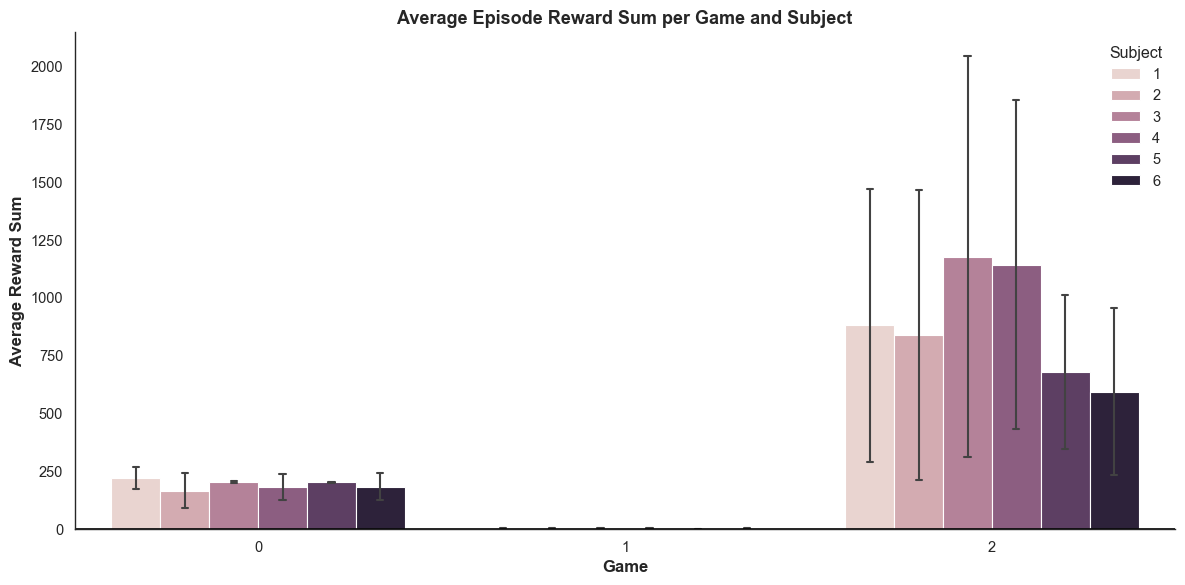

In [3]:
# reward sum 저장용 리스트
reward_records = []

# 전체 폴더 순회
for sub_dir in base_path.glob("sub_*"):
    sub_id = int(sub_dir.name.split("_")[1])  # "sub_3" → 3

    for game_dir in sub_dir.glob("game_*"):
        game_id = int(game_dir.name.split("_")[1])  # "game_0" → 0

        for npz_file in game_dir.glob("**/*.npz"):  # 🔥 하위 폴더까지 탐색
            try:
                data = np.load(npz_file)
                reward_sum = np.sum(data["reward"])
                reward_records.append({
                    "subject": sub_id,
                    "game": game_id,
                    "episode": npz_file.name,
                    "reward_sum": reward_sum
                })
            except Exception as e:
                print(f"Error loading {npz_file}: {e}")

# DataFrame 생성
df = pd.DataFrame(reward_records)

# 그룹 평균
df_grouped = df.groupby(["subject", "game"])["reward_sum"].mean().reset_index()

# 시각화
sns.set(style="white", context="paper", font_scale=1.2)
plt.figure(figsize=(12, 6))
sns.barplot(
    data=df,
    x="game",
    y="reward_sum",
    hue="subject",           # subject를 색깔로 구분
    errorbar="sd",
    err_kws={'linewidth': 1.5},
    capsize=0.1
)
plt.axhline(0, color="black", linewidth=1.2)
plt.ylim(bottom=0)
plt.xlabel("Game", fontsize=12, fontweight='bold')
plt.ylabel("Average Reward Sum", fontsize=12, fontweight='bold')
plt.title("Average Episode Reward Sum per Game and Subject", fontsize=13, fontweight='bold')
plt.legend(title="Subject", frameon=False)
plt.grid(False)
sns.despine()
plt.tight_layout()
plt.show()

#### per episode

In [4]:
reward_records = []

# 폴더 순회
for sub_dir in base_path.glob("sub_*"):
    sub_id = int(sub_dir.name.split("_")[1])  # sub_1 → 1

    for game_dir in sub_dir.glob("game_*"):
        game_id = int(game_dir.name.split("_")[1])  # game_0 → 0

        for npz_file in game_dir.glob("**/*.npz"):
            try:
                data = np.load(npz_file)
                reward_sum = np.sum(data["reward"])
                reward_records.append({
                    "subject": sub_id,
                    "game": game_id,
                    "episode": npz_file.name,
                    "reward_sum": reward_sum
                })
            except Exception as e:
                print(f"Error loading {npz_file}: {e}")

# DataFrame 생성
df = pd.DataFrame(reward_records)

# 평균 ± 표준편차 계산
stats_df = df.groupby(['game', 'subject'])['reward_sum'].agg(['mean', 'std']).reset_index()
stats_df['mean_std'] = stats_df.apply(lambda row: f"{row['mean']:.2f} ± {row['std']:.2f}", axis=1)

# 피벗 테이블 생성
pivot_table = stats_df.pivot(index='game', columns='subject', values='mean_std').sort_index(axis=1)

# 게임 이름 매핑
game_names = {0: "Enduro", 1: "Pong", 2: "Space Invaders"}
pivot_table.index = pivot_table.index.map(game_names)

# 게임 순서 재정렬
desired_order = ["Pong", "Enduro", "Space Invaders"]
pivot_table = pivot_table.reindex(desired_order)

# 테이블 생성
gt_tbl = (
    GT(pivot_table.reset_index())
    .tab_header(
        title=md("**Episode Reward Summary**"),
        subtitle="Mean ± SD of Rewards per Game × Subject"
    )
    .tab_stub(rowname_col="game")  # reset_index() 했으니까 컬럼명이 "game"
    .tab_stubhead(label="Game/Subject")
    .tab_source_note(source_note=md("Each cell reports `mean ± std` of episode reward sums."))
)

# 표 출력
gt_tbl.show()

c:\Users\jmme4\miniconda3\envs\thinker\lib\site-packages\great_tables\_tbl_data.py:797: UserWarning: pandas DataFrame contains non-string column names. Coercing to strings. Here are the first few non-string columns:

  * Position 1: 1
  * Position 2: 2
  * Position 3: 3
  warnings.warn(


Episode Reward Summary 
 
 
 Mean ± SD of Rewards per Game × Subject 
 
 
 Game/Subject 
 1 
 2 
 3 
 4 
 5 
 6 
 
 
 
 
 Pong 
 -0.64 ± 3.67 
 0.73 ± 2.83 
 -1.91 ± 4.53 
 1.55 ± 3.33 
 -3.09 ± 2.77 
 -0.09 ± 2.34 
 
 
 Enduro 
 221.25 ± 47.58 
 164.57 ± 74.98 
 202.27 ± 3.95 
 181.75 ± 57.72 
 201.82 ± 1.99 
 182.75 ± 57.72 
 
 
 Space Invaders 
 880.30 ± 589.92 
 836.85 ± 626.25 
 1177.19 ± 868.09 
 1142.57 ± 712.64 
 677.39 ± 333.51 
 593.59 ± 360.91 
 
 
 
 
 
 Each cell reports mean ± std of episode reward sums.

#### per block

In [5]:
reward_records = []

# 폴더 순회
for sub_dir in base_path.glob("sub_*"):
    sub_id = int(sub_dir.name.split("_")[1])

    for game_dir in sub_dir.glob("game_*"):
        game_id = int(game_dir.name.split("_")[1])

        for npz_file in game_dir.glob("**/*.npz"):
            try:
                # 파일 이름에서 day와 block 추출
                # 예: sub5-game1-day0-block0-episode0-5864.npz
                parts = npz_file.name.split('-')
                day = int(parts[2][3:])    # day0 → 0
                block = int(parts[3][5:])  # block0 → 0

                data = np.load(npz_file)
                reward_sum = np.sum(data["reward"])
                
                reward_records.append({
                    "subject": sub_id,
                    "game": game_id,
                    "day": day,
                    "block": block,
                    "reward_sum": reward_sum
                })
            except Exception as e:
                print(f"Error loading {npz_file}: {e}")

# 🛠️ DataFrame 생성
df = pd.DataFrame(reward_records)

# 🛠️ block 단위로 평균 계산
# 같은 subject, game, day, block끼리 묶어서 reward_sum 평균
block_df = df.groupby(['subject', 'game', 'day', 'block'])['reward_sum'].mean().reset_index()

# 🛠️ block별 reward 합을 다시 game과 subject별로 평균 및 표준편차 계산
stats_df = block_df.groupby(['game', 'subject'])['reward_sum'].agg(['mean', 'std']).reset_index()
stats_df['mean_std'] = stats_df.apply(lambda row: f"{row['mean']:.2f} ± {row['std']:.2f}", axis=1)

# 🛠️ 피벗 테이블 생성
pivot_table = stats_df.pivot(index='game', columns='subject', values='mean_std').sort_index(axis=1)

# 게임 이름 매핑
game_names = {0: "Enduro", 1: "Pong", 2: "Space Invaders"}
pivot_table.index = pivot_table.index.map(game_names)

# 게임 순서 재정렬
desired_order = ["Pong", "Enduro", "Space Invaders"]
pivot_table = pivot_table.reindex(desired_order)

# 🛠️ GreatTables로 표 생성
gt_tbl = (
    GT(pivot_table.reset_index())
    .tab_header(
        title=md("**Block-wise Reward Summary**"),
        subtitle="Mean ± SD of Block Rewards per Game × Subject"
    )
    .tab_stub(rowname_col="game")  # reset_index() 했으니까 컬럼명이 "game"
    .tab_stubhead(label="Game/Subject")
    .tab_source_note(source_note=md("Each cell reports `mean ± std` of block reward sums."))
)

# 표 출력
gt_tbl.show()

# 저장
#gt_tbl.save(file="block_reward_summary.png")

c:\Users\jmme4\miniconda3\envs\thinker\lib\site-packages\great_tables\_tbl_data.py:797: UserWarning: pandas DataFrame contains non-string column names. Coercing to strings. Here are the first few non-string columns:

  * Position 1: 1
  * Position 2: 2
  * Position 3: 3
  warnings.warn(


Block-wise Reward Summary 
 
 
 Mean ± SD of Block Rewards per Game × Subject 
 
 
 Game/Subject 
 1 
 2 
 3 
 4 
 5 
 6 
 
 
 
 
 Pong 
 -0.64 ± 3.67 
 0.73 ± 2.83 
 -1.91 ± 4.53 
 1.55 ± 3.33 
 -3.09 ± 2.77 
 -0.09 ± 2.34 
 
 
 Enduro 
 227.05 ± 42.84 
 183.71 ± 43.79 
 202.27 ± 3.95 
 190.32 ± 34.12 
 201.82 ± 1.99 
 190.91 ± 32.49 
 
 
 Space Invaders 
 961.94 ± 344.80 
 914.68 ± 321.25 
 1301.80 ± 470.72 
 1202.35 ± 317.45 
 696.69 ± 160.33 
 597.52 ± 74.22 
 
 
 
 
 
 Each cell reports mean ± std of block reward sums.

C:\Users\jmme4\AppData\Local\Temp\ipykernel_23176\1606812282.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


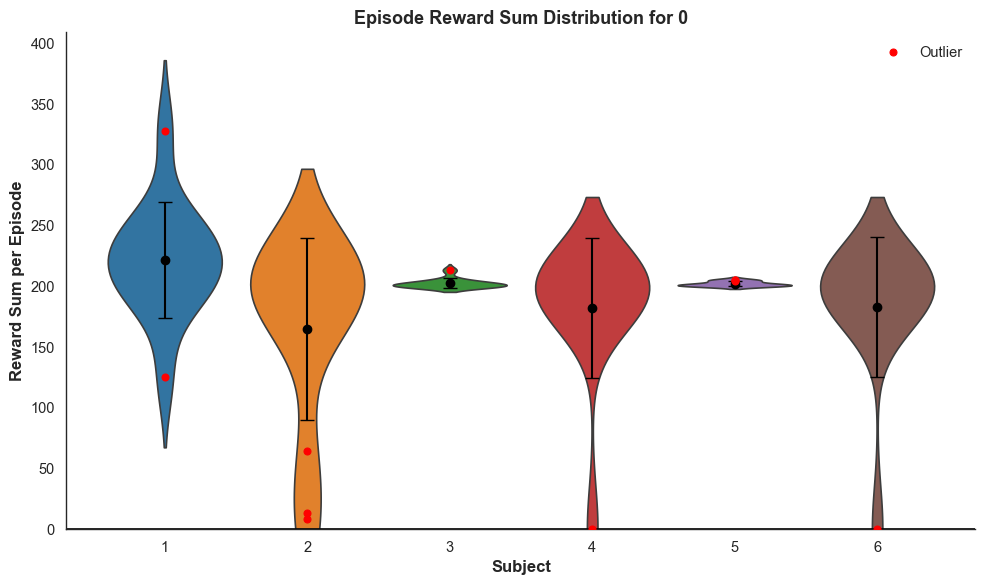

C:\Users\jmme4\AppData\Local\Temp\ipykernel_23176\1606812282.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


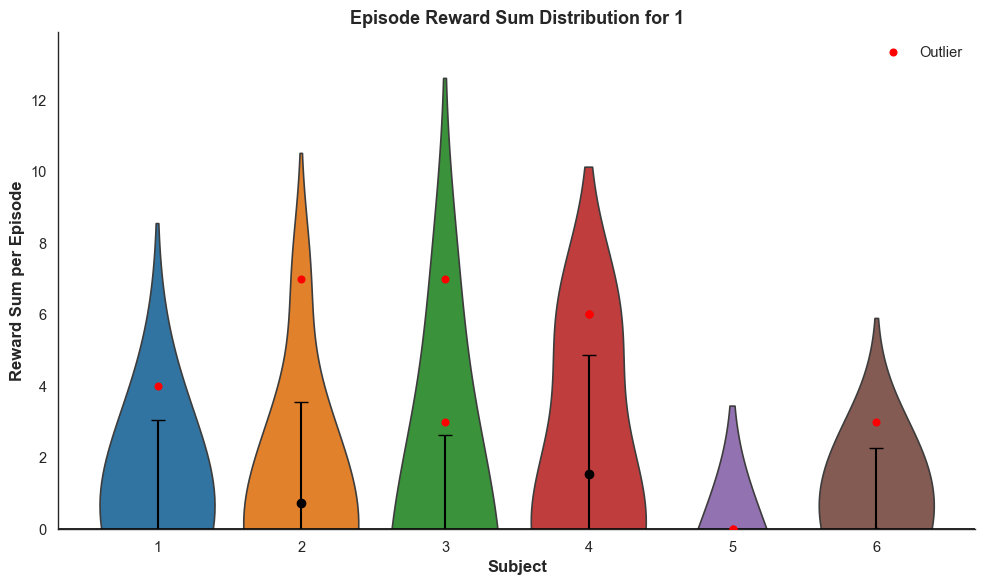

C:\Users\jmme4\AppData\Local\Temp\ipykernel_23176\1606812282.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


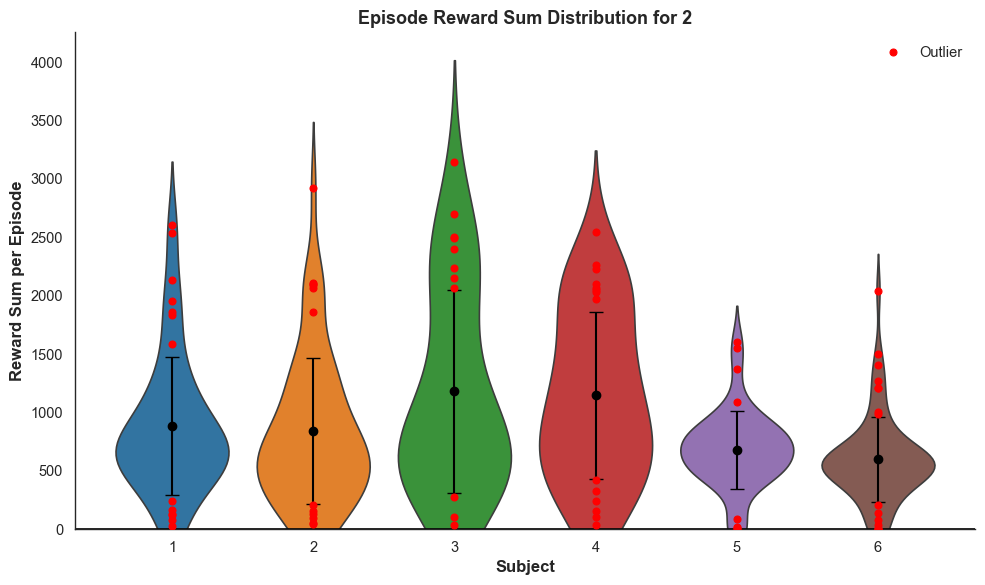

In [6]:
# 시각화
sns.set(style="white", context="paper", font_scale=1.2)

# 게임 종류 가져오기
games = df['game'].unique()

for game in games:
    plt.figure(figsize=(10, 6))
    
    # 특정 게임에 해당하는 데이터만 선택
    df_game = df[df['game'] == game]
    
    # subject별로 평균과 표준편차 계산
    stats = df_game.groupby('subject')['reward_sum'].agg(['mean', 'std']).reset_index()

    # Violin plot
    sns.violinplot(
        data=df_game,
        x="subject",
        y="reward_sum",
        inner=None,  # 내부 strip 제거
        linewidth=1.2,
        palette='tab10'
    )

    # 평균과 표준편차를 error bar로 표시
    for i, row in stats.iterrows():
        plt.errorbar(
            x=i,  # subject 순서대로 인덱스
            y=row['mean'],
            yerr=row['std'],
            fmt='o',
            color='black',
            capsize=5,
            markersize=6,
            elinewidth=1.5
        )

    # 표준편차를 벗어나는 점들만 따로 표시
    for i, subject in enumerate(stats['subject']):
        subject_data = df_game[df_game['subject'] == subject]
        mean = stats.loc[stats['subject'] == subject, 'mean'].values[0]
        std = stats.loc[stats['subject'] == subject, 'std'].values[0]
        
        # SD 벗어나는 episode만 필터링
        outlier_data = subject_data[
            (subject_data['reward_sum'] > mean + std) | (subject_data['reward_sum'] < mean - std)
        ]
        
        # outlier 점 찍기
        plt.scatter(
            [i] * len(outlier_data),  # x좌표 (subject별 위치에 맞춰)
            outlier_data['reward_sum'],
            color='red',
            edgecolor='red',
            zorder=5,
            s=25,
            label='Outlier' if i == 0 else ""  # 범례는 한번만
        )

    plt.axhline(0, color="black", linewidth=1.2)
    plt.ylim(bottom=0)
    plt.xlabel("Subject", fontsize=12, fontweight='bold')
    plt.ylabel("Reward Sum per Episode", fontsize=12, fontweight='bold')
    plt.title(f"Episode Reward Sum Distribution for {game}", fontsize=13, fontweight='bold')
    plt.legend(frameon=False)
    plt.grid(False)
    sns.despine()
    plt.tight_layout()
    plt.show()

C:\Users\jmme4\AppData\Local\Temp\ipykernel_28788\1701852457.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


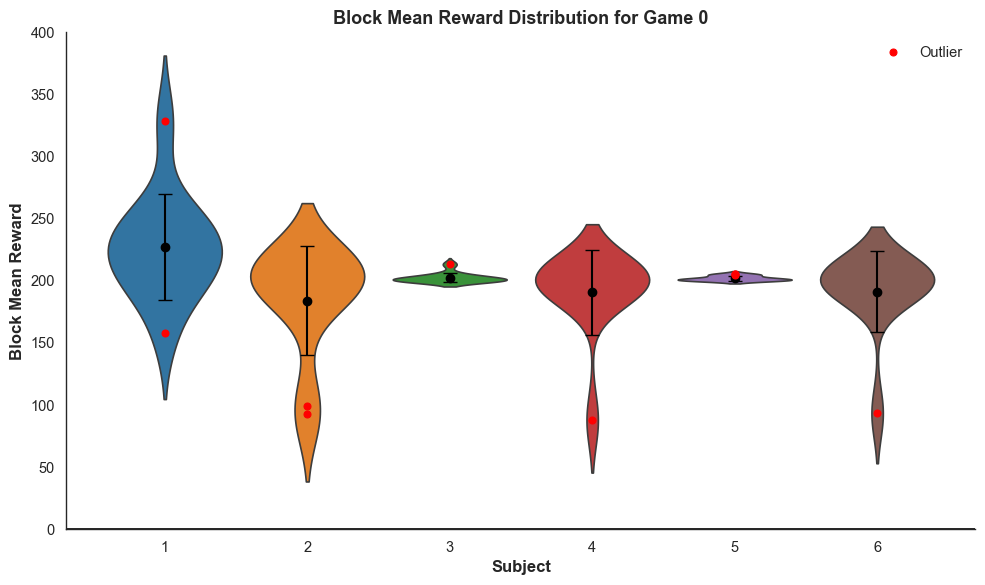

C:\Users\jmme4\AppData\Local\Temp\ipykernel_28788\1701852457.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


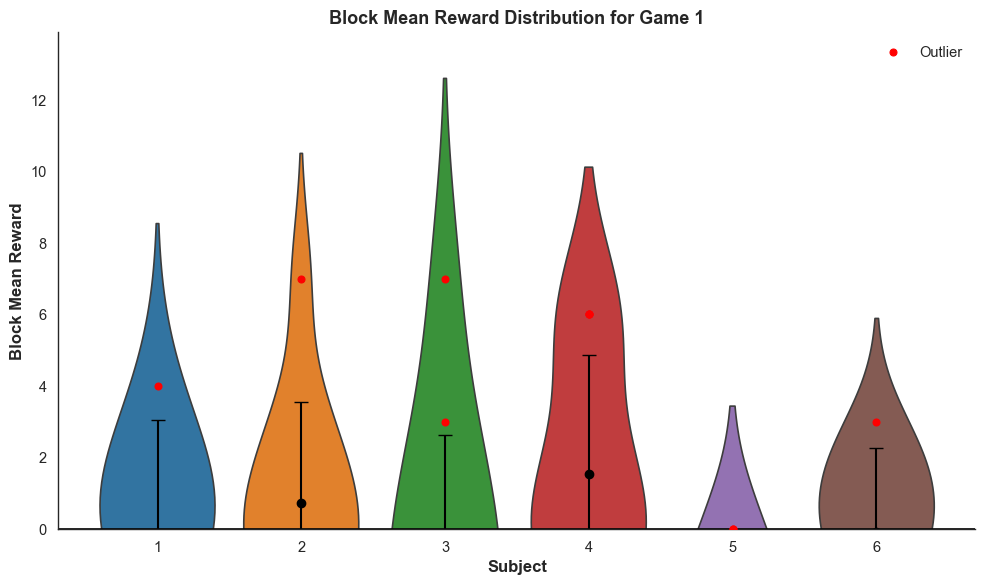

C:\Users\jmme4\AppData\Local\Temp\ipykernel_28788\1701852457.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


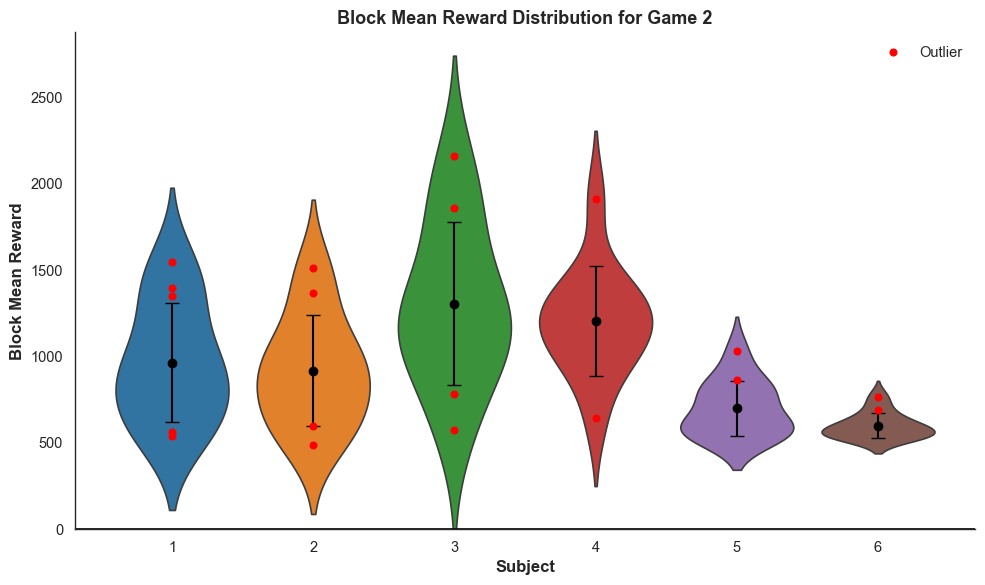

In [7]:
df_block = (
    df.groupby(['subject', 'game', 'day', 'block'])['reward_sum']
    .mean()
    .reset_index()
)

# 🎨 시각화
sns.set(style="white", context="paper", font_scale=1.2)

# 게임 종류 가져오기
games = df_block['game'].unique()

for game in games:
    plt.figure(figsize=(10, 6))
    
    df_game = df_block[df_block['game'] == game]

    stats = df_game.groupby('subject')['reward_sum'].agg(['mean', 'std']).reset_index()

    sns.violinplot(
        data=df_game,
        x="subject",
        y="reward_sum",
        inner=None,
        linewidth=1.2,
        palette='tab10'   # subject별 색깔 다르게
    )

    for i, row in stats.iterrows():
        plt.errorbar(
            x=i,
            y=row['mean'],
            yerr=row['std'],
            fmt='o',
            color='black',
            capsize=5,
            markersize=6,
            elinewidth=1.5
        )

    for i, subject in enumerate(stats['subject']):
        subject_data = df_game[df_game['subject'] == subject]
        mean = stats.loc[stats['subject'] == subject, 'mean'].values[0]
        std = stats.loc[stats['subject'] == subject, 'std'].values[0]
        
        outlier_data = subject_data[
            (subject_data['reward_sum'] > mean + std) | (subject_data['reward_sum'] < mean - std)
        ]
        
        plt.scatter(
            [i] * len(outlier_data),
            outlier_data['reward_sum'],
            color='red',
            edgecolor='red',
            zorder=5,
            s=25,
            label='Outlier' if i == 0 else ""
        )

    plt.axhline(0, color="black", linewidth=1.2)
    plt.ylim(bottom=0)
    plt.xlabel("Subject", fontsize=12, fontweight='bold')
    plt.ylabel("Block Mean Reward", fontsize=12, fontweight='bold')
    plt.title(f"Block Mean Reward Distribution for Game {game}", fontsize=13, fontweight='bold')
    plt.legend(frameon=False)
    plt.grid(False)
    sns.despine()
    plt.tight_layout()
    plt.show()

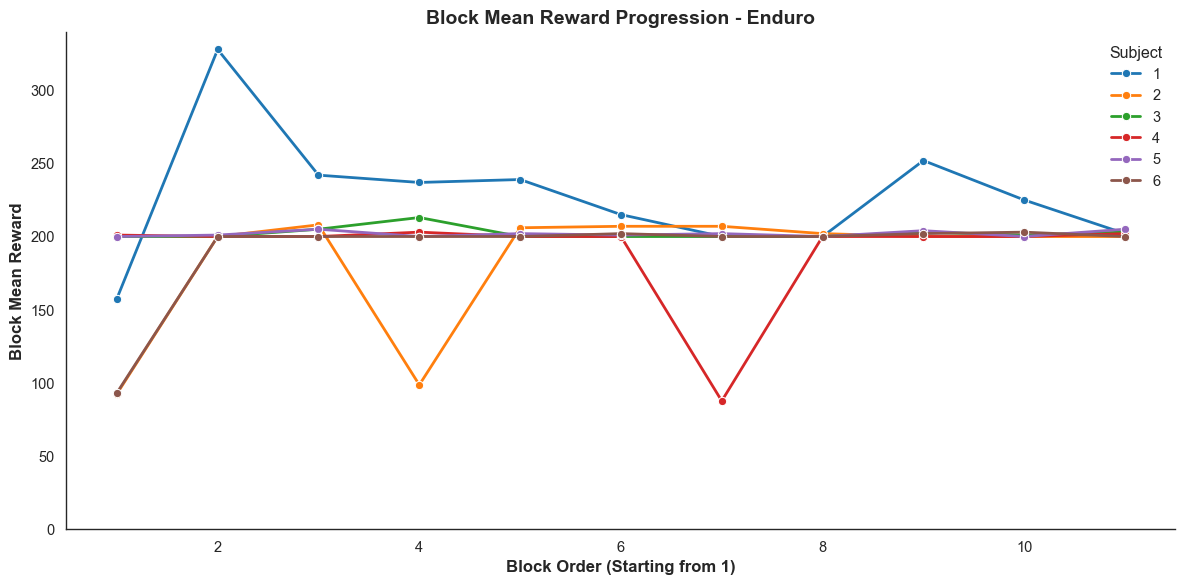

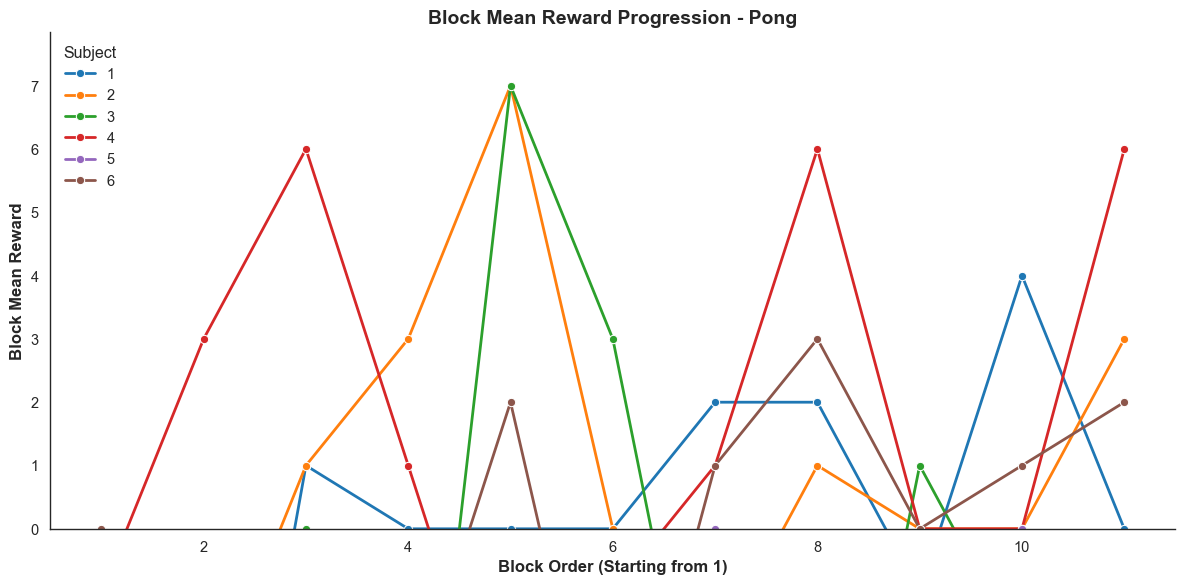

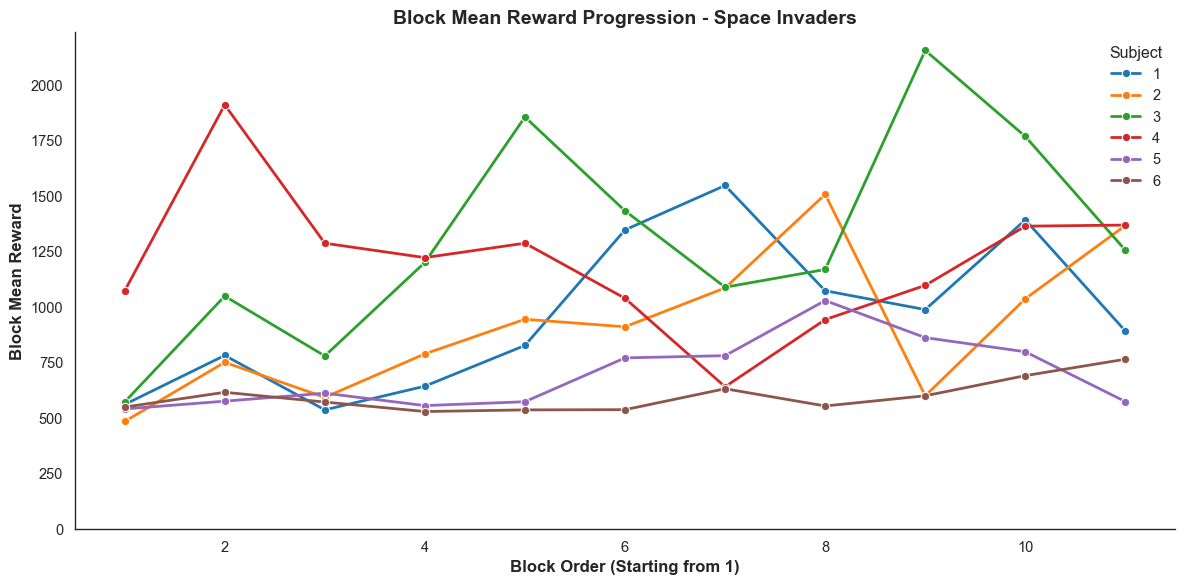

In [7]:
df_block = (
    df.groupby(['subject', 'game', 'day', 'block'])['reward_sum']
    .mean()
    .reset_index()
)

# 각 subject/game 그룹별로 block 순서 매기기
df_block['block_order'] = (
    df_block
    .sort_values(['subject', 'game', 'day', 'block'])
    .groupby(['subject', 'game'])
    .cumcount() + 1
)

# 🎨 시각화
sns.set(style="white", context="paper", font_scale=1.2)

games = df_block['game'].unique()
game_names = {0: "Enduro", 1: "Pong", 2: "Space Invaders"}

for game in games:
    plt.figure(figsize=(12, 6))
    
    df_game = df_block[df_block['game'] == game]

    sns.lineplot(
        data=df_game,
        x="block_order",     # ✅ block 번호가 아니라 block 순서
        y="reward_sum",
        hue="subject",       # subject별 색깔
        marker="o",
        linewidth=2.0,
        markersize=6,
        palette="tab10"
    )

    plt.xlabel("Block Order (Starting from 1)", fontsize=12, fontweight='bold')
    plt.ylabel("Block Mean Reward", fontsize=12, fontweight='bold')
    plt.title(f"Block Mean Reward Progression - {game_names[game]}", fontsize=14, fontweight='bold')
    plt.legend(title="Subject", frameon=False)
    plt.ylim(bottom=0)

    plt.grid(False)
    sns.despine()
    plt.tight_layout()
    plt.show()

C:\Users\jmme4\AppData\Local\Temp\ipykernel_23176\1306833213.py:192: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


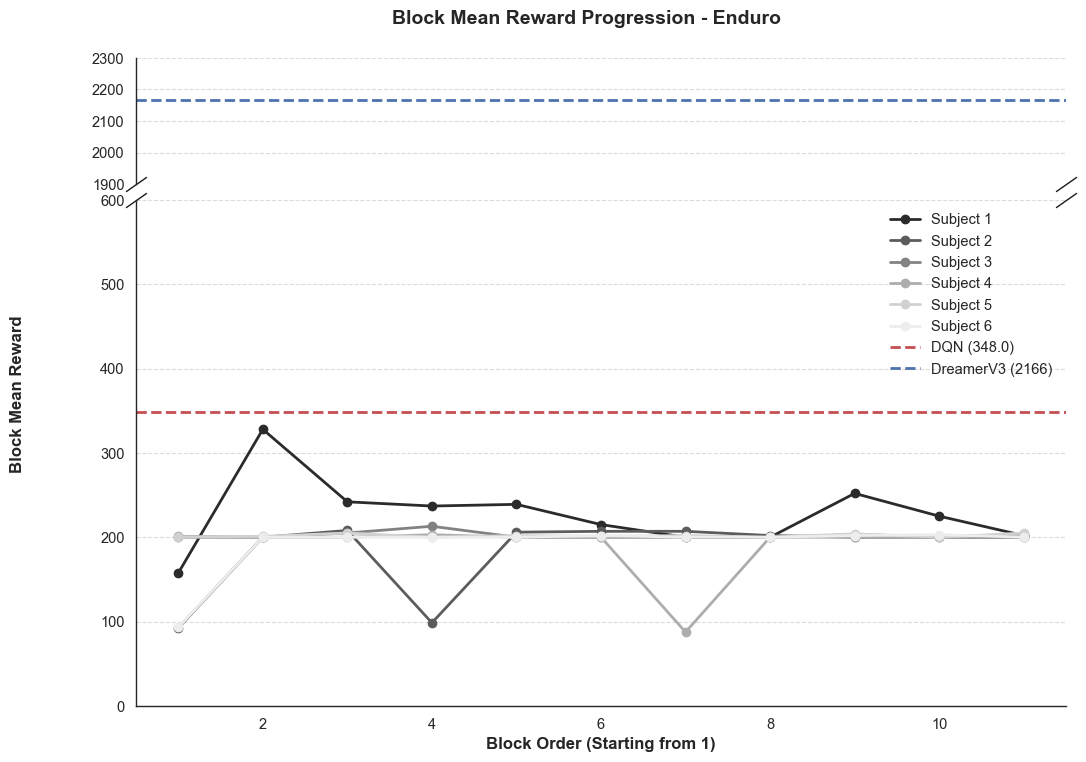

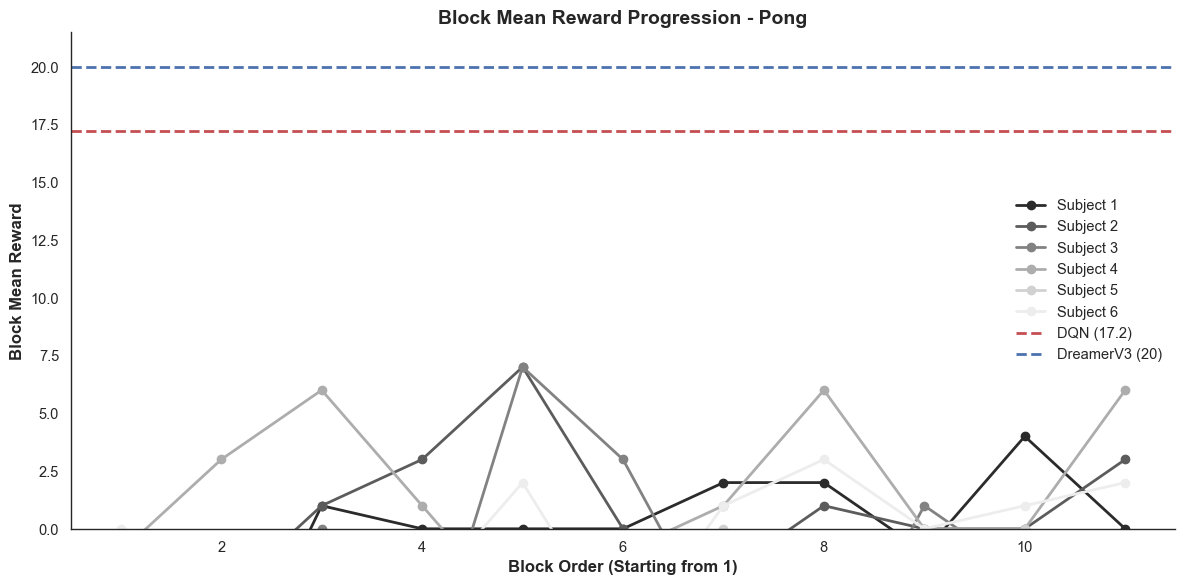

C:\Users\jmme4\AppData\Local\Temp\ipykernel_23176\1306833213.py:192: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


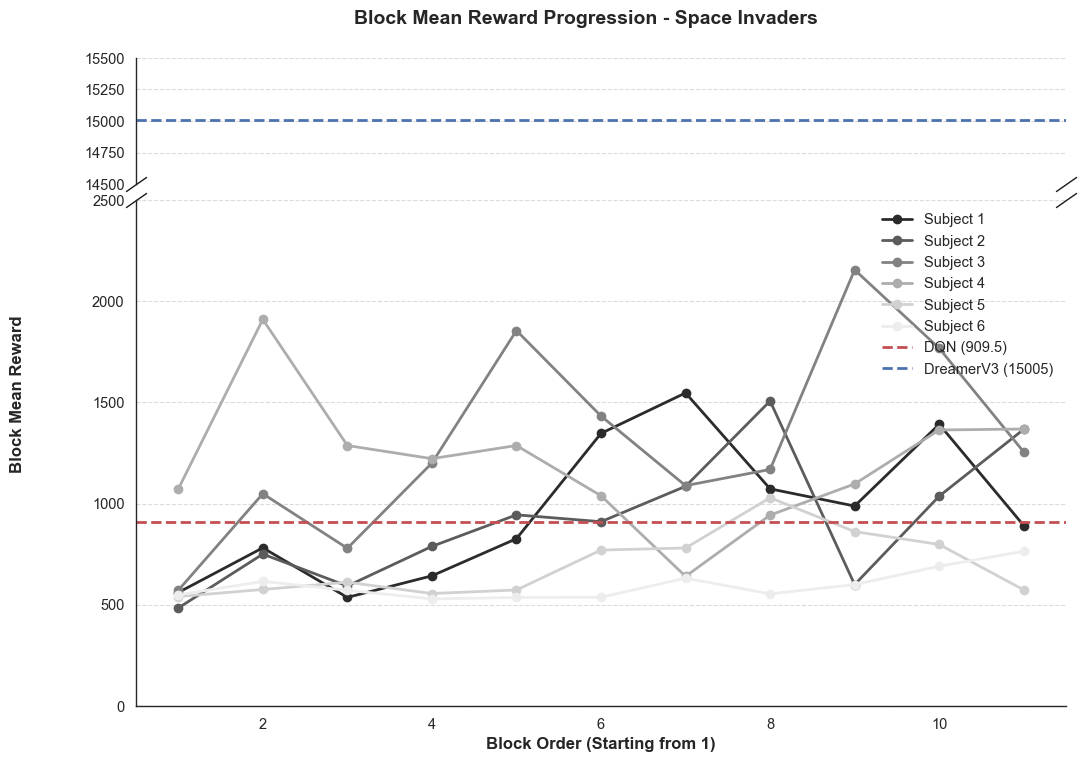

In [8]:
df_block = (
    df.groupby(['subject', 'game', 'day', 'block'])['reward_sum']
    .mean()
    .reset_index()
)

# 각 subject/game 그룹별로 block 순서 매기기
df_block['block_order'] = (
    df_block
    .sort_values(['subject', 'game', 'day', 'block'])
    .groupby(['subject', 'game'])
    .cumcount() + 1
)

# 표준편차 계산을 위한 데이터프레임 준비
# 원본 데이터에 block_order 정보 추가
df_with_order = df.copy()
# 각 subject, game, day, block 조합에 해당하는 block_order 찾기
order_mapping = df_block[['subject', 'game', 'day', 'block', 'block_order']].drop_duplicates()
# 원본 데이터에 병합
df_with_order = pd.merge(
    df_with_order, 
    order_mapping, 
    on=['subject', 'game', 'day', 'block'], 
    how='left'
)

# 🎨 시각화 - 흑백 스케일로 변경
sns.set(style="white", context="paper", font_scale=1.2)

games = df_block['game'].unique()
game_names = {0: "Enduro", 1: "Pong", 2: "Space Invaders"}
dqn_values = {
    0: {"mean": 348.0, "std": 0},     # Enduro
    1: {"mean": 17.2, "std": 0},      # Pong
    2: {"mean": 909.50, "std": 0}     # Space Invaders
}
dreamer_values = {
    0: {"mean": 2166, "std": 0},     # Enduro
    1: {"mean": 20, "std": 0},      # Pong
    2: {"mean": 15005, "std": 0}     # Space Invaders
}

# 흑백 팔레트 생성 - 회색조 스케일
gray_palette = sns.color_palette("Greys_r", n_colors=len(df_block['subject'].unique()))

for game in games:
    if game == 1:  # Pong: 일반 방식으로 그래프 표시 (scale 차이가 작음)
        plt.figure(figsize=(12, 6))
        
        df_game = df_block[df_block['game'] == game]

        # 각 subject별 표준편차 계산 및 표준편차 쉐이딩 추가
        for i, subject in enumerate(df_game['subject'].unique()):
            df_subj = df_game[df_game['subject'] == subject]
            
            # 표준 편차 계산을 위한 그룹화
            std_data = (
                df_with_order[(df_with_order['subject'] == subject) & 
                              (df_with_order['game'] == game)]
                .groupby(['subject', 'game', 'block_order'])['reward_sum']
                .std()
                .reset_index()
            )
            
            # 평균과 표준편차
            mean_data = df_subj['reward_sum'].values
            x_values = df_subj['block_order'].values
            
            # 라인 플롯 (회색조 사용)
            plt.plot(x_values, mean_data, marker='o', linewidth=2.0, markersize=6, 
                    color=gray_palette[i], label=f"Subject {subject}")
            
            
        
        # DQN, dreamer 성능 수평선
        dqn_mean = dqn_values[game]["mean"]
        dqn_std = dqn_values[game]["std"]
        dreamer_mean = dreamer_values[game]["mean"]
        dreamer_std = dreamer_values[game]["std"]
        
        plt.axhline(y=dqn_mean, color='r', linestyle='--', linewidth=2, 
                   label=f"DQN ({dqn_mean})")
        plt.axhline(y=dreamer_mean, color='b', linestyle='--', linewidth=2, 
                   label=f"DreamerV3 ({dreamer_mean})")

        plt.xlabel("Block Order (Starting from 1)", fontsize=12, fontweight='bold')
        plt.ylabel("Block Mean Reward", fontsize=12, fontweight='bold')
        plt.title(f"Block Mean Reward Progression - {game_names[game]}", fontsize=14, fontweight='bold')
        plt.legend(title="", frameon=False)
        plt.ylim(bottom=0)

        plt.grid(False)
        sns.despine()
        plt.tight_layout()
        plt.show()
    else:  # Enduro, Space Invaders: 축이 끊어진 그래프 (broken y-axis)
        # 게임별 Y축 설정
        if game == 0:  # Enduro
            # 끊어진 Y축 범위 설정
            y_low_max = 600   # 아래쪽 축의 최대값
            y_high_min = 1900  # 위쪽 축의 최소값
            y_high_max = 2300  # 위쪽 축의 최대값
        else:  # Space Invaders
            y_low_max = 2500   # 아래쪽 축의 최대값
            y_high_min = 14500 # 위쪽 축의 최소값
            y_high_max = 15500 # 위쪽 축의 최대값
            
        # 두 개의 subplot 생성
        f, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, sharex=True, figsize=(12, 8), 
                                    gridspec_kw={'height_ratios': [1, 4], 'hspace': 0.05})
        
        df_game = df_block[df_block['game'] == game]
        
        # 각 subject별 데이터 그리기
        for i, subject in enumerate(df_game['subject'].unique()):
            df_subj = df_game[df_game['subject'] == subject]
            
            # 표준 편차 계산
            std_data = (
                df_with_order[(df_with_order['subject'] == subject) & 
                              (df_with_order['game'] == game)]
                .groupby(['subject', 'game', 'block_order'])['reward_sum']
                .std()
                .reset_index()
            )
            
            # 평균과 표준편차
            mean_data = df_subj['reward_sum'].values
            x_values = df_subj['block_order'].values
            
            # 아래쪽 subplot에 그리기
            ax2.plot(x_values, mean_data, marker='o', linewidth=2.0, markersize=6, 
                    color=gray_palette[i], label=f"Subject {subject}")
            
        
        
        # DQN 수평선 추가 (아래쪽 subplot)
        dqn_mean = dqn_values[game]["mean"]
        ax2.axhline(y=dqn_mean, color='r', linestyle='--', linewidth=2, 
                   label=f"DQN ({dqn_mean})")
        
        # DreamerV3 수평선 추가 (위쪽 subplot)
        dreamer_mean = dreamer_values[game]["mean"]
        ax1.axhline(y=dreamer_mean, color='b', linestyle='--', linewidth=2, 
                    label=f"DreamerV3 ({dreamer_mean})")
        
        # y축 범위 설정
        ax2.set_ylim(0, y_low_max)  # 아래쪽 subplot
        ax1.set_ylim(y_high_min, y_high_max)  # 위쪽 subplot
        
        # 그리드 설정
        ax1.yaxis.grid(True, linestyle='--', alpha=0.7)
        ax2.yaxis.grid(True, linestyle='--', alpha=0.7)
        
        # 축 테두리 제거
        ax1.spines['bottom'].set_visible(False)
        ax2.spines['top'].set_visible(False)
        
        # 축이 끊어진 표시 추가 (대각선)
        d = .7  # how big to make the diagonal lines in axes coordinates
        kwargs = dict(marker=[(-1, -d), (1, d)], markersize=15, linestyle="none", color='k', clip_on=False)
        ax1.plot([0, 1], [0, 0], transform=ax1.transAxes, **kwargs)
        ax2.plot([0, 1], [1, 1], transform=ax2.transAxes, **kwargs)
        
        # 레이블 설정
        ax1.set_ylabel("")
        ax2.set_ylabel("")
        f.text(0.02, 0.5, "Block Mean Reward", va='center', rotation='vertical', 
               fontsize=12, fontweight='bold')
        
        ax2.set_xlabel("Block Order (Starting from 1)", fontsize=12, fontweight='bold')
        
        # 타이틀 설정
        plt.suptitle(f"Block Mean Reward Progression - {game_names[game]}", 
                    fontsize=14, fontweight='bold')
        
        # x축 레이블 설정
        ax1.get_xaxis().set_visible(False)
        
        # 범례 설정 (통합)
        handles1, labels1 = ax1.get_legend_handles_labels()
        handles2, labels2 = ax2.get_legend_handles_labels()
        ax2.legend(handles2 + handles1, labels2 + labels1, 
                  loc='best', frameon=False)
        if ax1.get_legend() is not None:
            ax1.get_legend().remove()
        
        sns.despine(ax=ax1, bottom=True)
        sns.despine(ax=ax2, top=True)
        
        plt.tight_layout()
        plt.subplots_adjust(top=0.92)  # suptitle을 위한 공간 확보
        plt.show()

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path
from typing import List, Tuple
import math

def analyze_noop_frequency(
    base_path: str = "E:/behav/behavioral_data_4kframe_legacy",
    subjects: List[int] = [1, 2, 3, 4, 5, 6],  # 분석할 subject들 (복수 선택 가능)
    game_id: int = 1,  # game_0, game_1, game_2 중 선택
    window_size: int = 1000,  # sliding window 크기
    stride: int = 100  # sliding window stride
):
    """
    NOOP frequency 분석을 위한 함수
    
    Parameters:
    -----------
    base_path : str
        데이터 경로
    subjects : List[int]
        분석할 subject 번호들 (복수 선택 가능)
    game_id : int
        분석할 게임 번호 (0: Enduro, 1: Pong, 2: Space Invaders)
    window_size : int
        sliding window 크기
    stride : int
        sliding window stride
    """
    
    base_path = Path(base_path)
    game_names = {0: "Enduro", 1: "Pong", 2: "Space Invaders"}
    
    # 각 npz 파일별로 NOOP frequency 분석
    for subject in subjects:
        sub_dir = base_path / f"sub_{subject}"
        game_dir = sub_dir / f"game_{game_id}"
        
        if not game_dir.exists():
            print(f"경로가 존재하지 않습니다: {game_dir}")
            continue
            
        # 해당 subject/game의 모든 npz 파일 찾기
        npz_files = list(game_dir.glob("**/*.npz"))
        
        if not npz_files:
            print(f"NPZ 파일을 찾을 수 없습니다: {game_dir}")
            continue
            
        print(f"Subject {subject}, Game {game_names[game_id]}: {len(npz_files)}개 파일 분석 중...")
        
        # 그리드 레이아웃 계산
        num_files = len(npz_files)
        cols = 4  # 가로 4개
        rows = math.ceil(num_files / cols)  # 세로는 파일 개수에 맞춰서
        
        # 전체 그래프 생성
        fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
        if rows == 1:
            axes = axes.reshape(1, -1)
        
        # 각 npz 파일별로 그래프 생성
        for idx, npz_file in enumerate(npz_files):
            try:
                # 데이터 로드
                data = np.load(npz_file)
                actions = data["action"]  # shape: (T, num_actions)
                
                # NOOP (action[:, 0] == 1) 개수 계산
                noop_actions = actions[:, 0]  # NOOP은 첫 번째 열 (인덱스 0)
                total_noops = np.sum(noop_actions)
                
                if total_noops == 0:
                    print(f"  {npz_file.name}: NOOP 액션이 없습니다.")
                    continue
                
                # Sliding window를 통한 NOOP frequency 계산
                window_starts = []
                noop_frequencies = []
                
                # 전체 길이에서 window_size만큼씩 stride 간격으로 이동
                for start_idx in range(0, len(actions) - window_size + 1, stride):
                    end_idx = start_idx + window_size
                    
                    # 현재 window 내의 NOOP 액션들 추출
                    window_noops = noop_actions[start_idx:end_idx]
                    
                    # window 내에서 NOOP인 개수 계산
                    noop_count = np.sum(window_noops)
                    noop_freq = noop_count / window_size  # window 크기로 나누어 비율 계산
                    
                    window_starts.append(start_idx)
                    noop_frequencies.append(noop_freq)
                
                # 그리드 위치 계산
                row = idx // cols
                col = idx % cols
                
                # 그래프 그리기
                axes[row, col].plot(window_starts, noop_frequencies, 'b-', alpha=0.7)
                axes[row, col].set_xlabel('Window Start Index (Real Step)')
                axes[row, col].set_ylabel('NOOP Frequency')
                axes[row, col].set_title('NOOP Frequency Over Time (Real Steps Only)')
                axes[row, col].grid(True, alpha=0.3)
                
                # 파일 이름을 x축 라벨 아래에 표시
                axes[row, col].text(0.5, -0.2, npz_file.name, 
                                  transform=axes[row, col].transAxes, 
                                  ha='center', va='top', 
                                  fontsize=8, 
                                  bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgray', alpha=0.7))
                
                # 결과 출력
                total_actions = len(actions)
                overall_noop_freq = total_noops / total_actions
                avg_window_freq = np.mean(noop_frequencies)
                
                print(f"  {npz_file.name}:")
                print(f"    - 전체 액션 수: {total_actions}")
                print(f"    - NOOP 액션 수: {total_noops}")
                print(f"    - 전체 NOOP 빈도: {overall_noop_freq:.3f}")
                print(f"    - Window 수: {len(window_starts)}")
                print(f"    - 평균 Window NOOP 빈도: {avg_window_freq:.3f}")
                print()
                
            except Exception as e:
                print(f"  {npz_file.name} 처리 중 오류 발생: {e}")
                continue
        
        # 빈 서브플롯 숨기기
        for idx in range(num_files, rows * cols):
            row = idx // cols
            col = idx % cols
            axes[row, col].set_visible(False)
        
        plt.tight_layout()
        plt.subplots_adjust(bottom=0.1)  # 하단 여백 조정
        plt.show()

In [2]:
# 사용 예시
analyze_noop_frequency(
    subjects=[6],  # subject 1만 분석
    game_id=2,     # game_2 (Space Invaders)
    window_size=160,  # window 크기 100
    stride=12
)

경로가 존재하지 않습니다: E:/behav/behavioral_data_4kframe_legacy/sub_6/game_2


In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path
from typing import List, Tuple
import math

def analyze_noop_frequency(
    base_path: str = "E:/behav/behavioral_data_4kframe_legacy",
    subjects: List[int] = [1, 2, 3, 4, 5, 6],  # 분석할 subject들 (복수 선택 가능)
    game_id: int = 1,  # game_0, game_1, game_2 중 선택
    window_size: int = 1000,  # sliding window 크기
    stride: int = 100  # sliding window stride
):
    """
    NOOP frequency 분석을 위한 함수
    
    Parameters:
    -----------
    base_path : str
        데이터 경로
    subjects : List[int]
        분석할 subject 번호들 (복수 선택 가능)
    game_id : int
        분석할 게임 번호 (0: Enduro, 1: Pong, 2: Space Invaders)
    window_size : int
        sliding window 크기
    stride : int
        sliding window stride
    """
    
    base_path = Path(base_path)
    game_names = {0: "Enduro", 1: "Pong", 2: "Space Invaders"}
    
    # 전체 데이터를 저장할 리스트
    all_window_starts = []
    all_noop_frequencies = []
    
    # 각 npz 파일별로 NOOP frequency 분석
    for subject in subjects:
        sub_dir = base_path / f"sub_{subject}"
        game_dir = sub_dir / f"game_{game_id}"
        
        if not game_dir.exists():
            print(f"경로가 존재하지 않습니다: {game_dir}")
            continue
            
        # 해당 subject/game의 모든 npz 파일 찾기
        npz_files = list(game_dir.glob("**/*.npz"))
        
        if not npz_files:
            print(f"NPZ 파일을 찾을 수 없습니다: {game_dir}")
            continue
            
        print(f"Subject {subject}, Game {game_names[game_id]}: {len(npz_files)}개 파일 분석 중...")
        
        # 그리드 레이아웃 계산
        num_files = len(npz_files)
        cols = 4  # 가로 4개
        rows = math.ceil(num_files / cols)  # 세로는 파일 개수에 맞춰서
        
        # 전체 그래프 생성
        fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
        if rows == 1:
            axes = axes.reshape(1, -1)
        
        # 각 npz 파일별로 그래프 생성
        for idx, npz_file in enumerate(npz_files):
            try:
                # 데이터 로드
                data = np.load(npz_file)
                actions = data["action"]  # shape: (T, num_actions)
                rewards = data["reward"]  # shape: (T,)
                
                # NOOP (action[:, 0] == 1) 개수 계산
                noop_actions = actions[:, 0]  # NOOP은 첫 번째 열 (인덱스 0)
                total_noops = np.sum(noop_actions)
                
                if total_noops == 0:
                    print(f"  {npz_file.name}: NOOP 액션이 없습니다.")
                    continue
                
                # Sliding window를 통한 NOOP frequency 계산
                window_starts = []
                noop_frequencies = []
                
                # 전체 길이에서 window_size만큼씩 stride 간격으로 이동
                for start_idx in range(0, len(actions) - window_size + 1, stride):
                    end_idx = start_idx + window_size
                    
                    # 현재 window 내의 NOOP 액션들 추출
                    window_noops = noop_actions[start_idx:end_idx]
                    
                    # window 내에서 NOOP인 개수 계산
                    noop_count = np.sum(window_noops)
                    noop_freq = noop_count / window_size  # window 크기로 나누어 비율 계산
                    
                    window_starts.append(start_idx)
                    noop_frequencies.append(noop_freq)
                
                # 전체 데이터에 추가
                all_window_starts.extend(window_starts)
                all_noop_frequencies.extend(noop_frequencies)
                
                # 양수/음수 보상 지점 찾기
                positive_reward_indices = []
                negative_reward_indices = []
                
                for i in range(len(rewards)):
                    if rewards[i] > 0:  # 양수 보상
                        positive_reward_indices.append(i)
                    elif rewards[i] < 0:  # 음수 보상
                        negative_reward_indices.append(i)
                
                # 그리드 위치 계산
                row = idx // cols
                col = idx % cols
                
                # 그래프 그리기
                axes[row, col].plot(window_starts, noop_frequencies, 'b-', alpha=0.7)
                
                # 양수 보상 지점에 파란색 세모 마커 추가
                for pos_idx in positive_reward_indices:
                    # 해당 인덱스가 포함된 window 찾기
                    for i, start_idx in enumerate(window_starts):
                        if start_idx <= pos_idx < start_idx + window_size:
                            axes[row, col].scatter(start_idx, noop_frequencies[i], 
                                                 marker='v', color='blue', s=30, alpha=0.6)
                            break
                
                # 음수 보상 지점에 빨간색 세모 마커 추가
                for neg_idx in negative_reward_indices:
                    # 해당 인덱스가 포함된 window 찾기
                    for i, start_idx in enumerate(window_starts):
                        if start_idx <= neg_idx < start_idx + window_size:
                            axes[row, col].scatter(start_idx, noop_frequencies[i], 
                                                 marker='v', color='red', s=42, alpha=0.6)
                            break
                
                axes[row, col].set_xlabel('Window Start Index (Real Step)')
                axes[row, col].set_ylabel('NOOP Frequency')
                
                # Total Score 계산 및 제목에 포함 (줄바꿈으로 구분)
                total_score = np.sum(rewards)
                axes[row, col].set_title(f'NOOP Frequency Over Time (Real Steps Only)\nTotal Score: {total_score:.1f}')
                
                axes[row, col].grid(True, alpha=0.3)
                
                # 파일 이름을 x축 라벨 아래에 표시
                axes[row, col].text(0.5, -0.2, npz_file.name, 
                                  transform=axes[row, col].transAxes, 
                                  ha='center', va='top', 
                                  fontsize=8, 
                                  bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgray', alpha=0.7))
                
                # 결과 출력
                total_actions = len(actions)
                overall_noop_freq = total_noops / total_actions
                avg_window_freq = np.mean(noop_frequencies)
                
                print(f"  {npz_file.name}:")
                print(f"    - 전체 액션 수: {total_actions}")
                print(f"    - NOOP 액션 수: {total_noops}")
                print(f"    - 전체 NOOP 빈도: {overall_noop_freq:.3f}")
                print(f"    - Window 수: {len(window_starts)}")
                print(f"    - 평균 Window NOOP 빈도: {avg_window_freq:.3f}")
                print(f"    - 양수 보상 지점: {len(positive_reward_indices)}개")
                print(f"    - 음수 보상 지점: {len(negative_reward_indices)}개")
                print(f"    - Total Score: {total_score:.1f}")
                print()
                
            except Exception as e:
                print(f"  {npz_file.name} 처리 중 오류 발생: {e}")
                continue
        
        # 빈 서브플롯 숨기기
        for idx in range(num_files, rows * cols):
            row = idx // cols
            col = idx % cols
            axes[row, col].set_visible(False)
        
        plt.tight_layout()
        plt.subplots_adjust(bottom=0.1)  # 하단 여백 조정
        plt.show()
    
    # 전체 데이터의 평균 NOOP frequency 그래프 생성
    if all_window_starts and all_noop_frequencies:
        print("전체 파일들의 평균 NOOP frequency 그래프 생성 중...")
        
        # DataFrame으로 변환하여 groupby로 평균 계산
        df = pd.DataFrame({
            'window_start': all_window_starts,
            'noop_frequency': all_noop_frequencies
        })
        
        # window_start별로 평균 계산
        avg_data = df.groupby('window_start')['noop_frequency'].mean().reset_index()
        
        # 평균 그래프 생성
        plt.figure(figsize=(12, 6))
        plt.plot(avg_data['window_start'], avg_data['noop_frequency'], 'g-', linewidth=2, alpha=0.8)
        plt.xlabel('Window Start Index (Real Step)')
        plt.ylabel('Average NOOP Frequency')
        plt.title(f'Average NOOP Frequency Across All Files - {game_names[game_id]}')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        print(f"평균 그래프 완성: {len(avg_data)}개의 window 지점")
        print(f"전체 파일 수: {len(npz_files)}개")
        print(f"총 데이터 포인트: {len(all_window_starts)}개")

Subject 1, Game Pong: 11개 파일 분석 중...
  sub1-game1-day1-block1-episode0-4468.npz:
    - 전체 액션 수: 4468
    - NOOP 액션 수: 3859.0
    - 전체 NOOP 빈도: 0.864
    - Window 수: 2155
    - 평균 Window NOOP 빈도: 0.865
    - 양수 보상 지점: 7개
    - 음수 보상 지점: 14개
    - Total Score: -7.0

  sub1-game1-day1-block4-episode0-4473.npz:
    - 전체 액션 수: 4473
    - NOOP 액션 수: 4055.0
    - 전체 NOOP 빈도: 0.907
    - Window 수: 2157
    - 평균 Window NOOP 빈도: 0.908
    - 양수 보상 지점: 6개
    - 음수 보상 지점: 14개
    - Total Score: -8.0

  sub1-game1-day2-block5-episode0-3336.npz:
    - 전체 액션 수: 3336
    - NOOP 액션 수: 2975.0
    - 전체 NOOP 빈도: 0.892
    - Window 수: 1589
    - 평균 Window NOOP 빈도: 0.894
    - 양수 보상 지점: 6개
    - 음수 보상 지점: 5개
    - Total Score: 1.0

  sub1-game1-day2-block7-episode0-3327.npz:
    - 전체 액션 수: 3327
    - NOOP 액션 수: 3072.0
    - 전체 NOOP 빈도: 0.923
    - Window 수: 1584
    - 평균 Window NOOP 빈도: 0.925
    - 양수 보상 지점: 4개
    - 음수 보상 지점: 4개
    - Total Score: 0.0

  sub1-game1-day2-block9-episode0-3321.npz:
    - 전체 액션

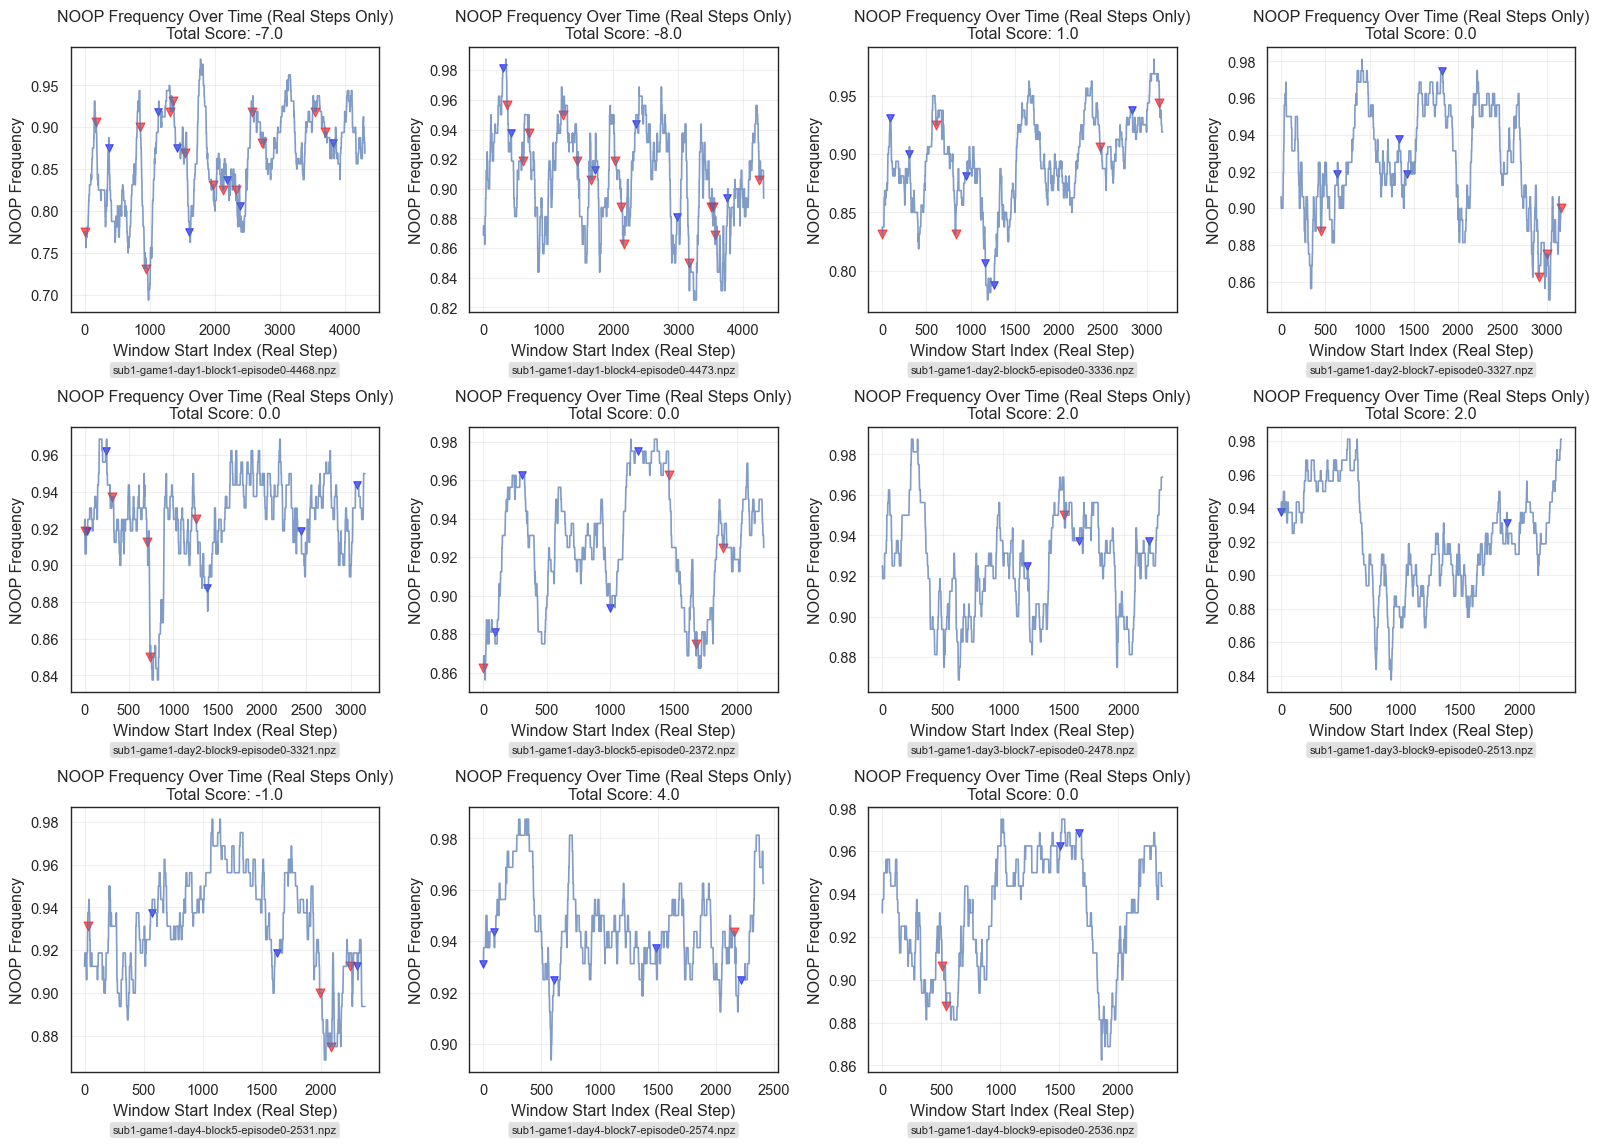

전체 파일들의 평균 NOOP frequency 그래프 생성 중...


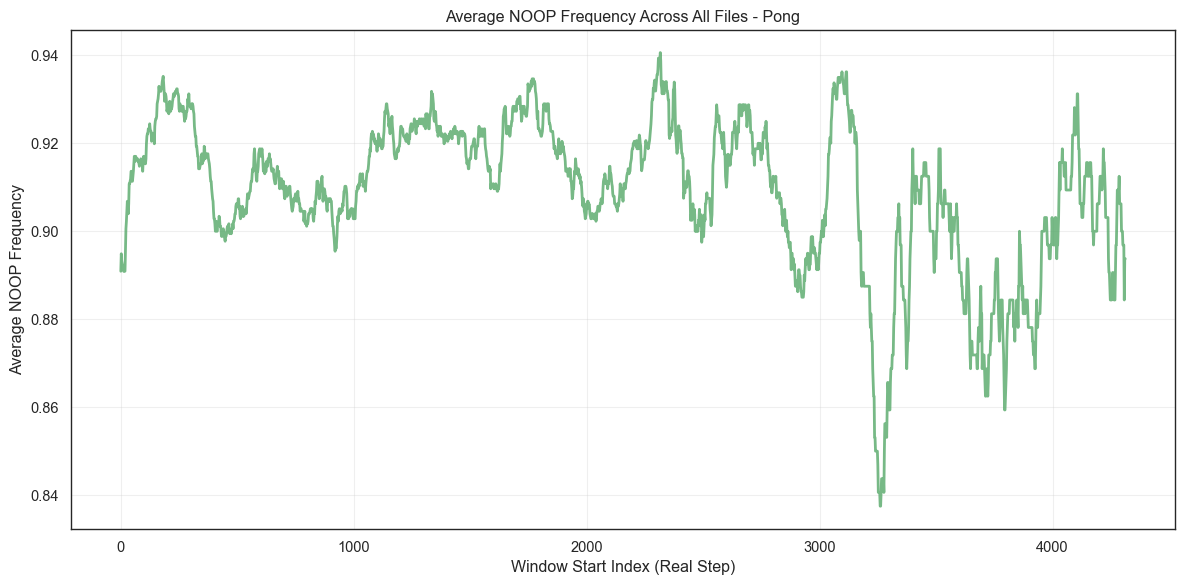

평균 그래프 완성: 2157개의 window 지점
전체 파일 수: 11개
총 데이터 포인트: 16093개


In [17]:
analyze_noop_frequency(
    subjects=[1],  # subject 1만 분석
    game_id=1,     # game_2 (Space Invaders)
    window_size=160,  # window 크기 100
    stride=2
)

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path
from typing import List, Tuple
import math

def analyze_noop_frequency2(
    base_path: str = "E:/behav/behavioral_data_4kframe_legacy",
    subjects: List[int] = [1, 2, 3, 4, 5, 6],  # 분석할 subject들 (복수 선택 가능)
    game_id: int = 1,  # game_0, game_1, game_2 중 선택
    window_size: int = 1000,  # sliding window 크기
    stride: int = 100  # sliding window stride
):
    """
    NOOP frequency 분석을 위한 함수
    
    Parameters:
    -----------
    base_path : str
        데이터 경로
    subjects : List[int]
        분석할 subject 번호들 (복수 선택 가능)
    game_id : int
        분석할 게임 번호 (0: Enduro, 1: Pong, 2: Space Invaders)
    window_size : int
        sliding window 크기
    stride : int
        sliding window stride
    """
    
    base_path = Path(base_path)
    game_names = {0: "Enduro", 1: "Pong", 2: "Space Invaders"}
    
    # 전체 데이터를 저장할 리스트
    all_window_starts = []
    all_noop_frequencies = []
    
    # 각 npz 파일별로 NOOP frequency 분석
    for subject in subjects:
        sub_dir = base_path / f"sub_{subject}"
        game_dir = sub_dir / f"game_{game_id}"
        
        if not game_dir.exists():
            print(f"경로가 존재하지 않습니다: {game_dir}")
            continue
            
        # 해당 subject/game의 모든 npz 파일 찾기
        npz_files = list(game_dir.glob("**/*.npz"))
        
        if not npz_files:
            print(f"NPZ 파일을 찾을 수 없습니다: {game_dir}")
            continue
            
        print(f"Subject {subject}, Game {game_names[game_id]}: {len(npz_files)}개 파일 분석 중...")
        
        # 그리드 레이아웃 계산
        num_files = len(npz_files)
        cols = 4  # 가로 4개
        rows = math.ceil(num_files / cols)  # 세로는 파일 개수에 맞춰서
        
        # 전체 그래프 생성
        fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
        if rows == 1:
            axes = axes.reshape(1, -1)
        
        # 각 npz 파일별로 그래프 생성
        for idx, npz_file in enumerate(npz_files):
            try:
                # 데이터 로드
                data = np.load(npz_file)
                actions = data["action"]  # shape: (T, num_actions)
                rewards = data["reward"]  # shape: (T,)
                
                # NOOP (action[:, 0] == 1) 개수 계산
                noop_actions = actions[:, 0]  # NOOP은 첫 번째 열 (인덱스 0)
                total_noops = np.sum(noop_actions)
                
                if total_noops == 0:
                    print(f"  {npz_file.name}: NOOP 액션이 없습니다.")
                    continue
                
                # Sliding window를 통한 NOOP frequency 계산
                window_starts = []
                noop_frequencies = []
                
                # 전체 길이에서 window_size만큼씩 stride 간격으로 이동
                for start_idx in range(0, len(actions) - window_size + 1, stride):
                    end_idx = start_idx + window_size
                    
                    # 현재 window 내의 NOOP 액션들 추출
                    window_noops = noop_actions[start_idx:end_idx]
                    
                    # window 내에서 NOOP인 개수 계산
                    noop_count = np.sum(window_noops)
                    noop_freq = noop_count / window_size  # window 크기로 나누어 비율 계산
                    
                    window_starts.append(start_idx)
                    noop_frequencies.append(noop_freq)
                
                # 전체 데이터에 추가
                all_window_starts.extend(window_starts)
                all_noop_frequencies.extend(noop_frequencies)
                
                # Reward sum이 630의 배수를 처음 초과하는 지점 찾기
                reward_sum = 0
                milestone_indices = []
                next_milestone = 630  # 다음 목표 milestone
                
                for i in range(len(rewards)):
                    reward_sum += rewards[i]
                    # 630의 배수를 처음 초과하는 지점 찾기
                    if reward_sum >= next_milestone:
                        milestone_indices.append(i)
                        next_milestone += 630  # 다음 milestone으로 업데이트
                
                # 그리드 위치 계산
                row = idx // cols
                col = idx % cols
                
                # 그래프 그리기
                axes[row, col].plot(window_starts, noop_frequencies, 'b-', alpha=0.7)
                
                # 630의 배수 지점에 세모 마커 추가
                for milestone_idx in milestone_indices:
                    # 해당 인덱스가 포함된 window 찾기
                    for i, start_idx in enumerate(window_starts):
                        if start_idx <= milestone_idx < start_idx + window_size:
                            axes[row, col].scatter(start_idx, noop_frequencies[i], 
                                                 marker='v', color='orange', s=50, alpha=0.8)
                            break
                
                axes[row, col].set_xlabel('Window Start Index (Real Step)')
                axes[row, col].set_ylabel('NOOP Frequency')
                
                # Total Score 계산 및 제목에 포함 (줄바꿈으로 구분)
                total_score = np.sum(rewards)
                axes[row, col].set_title(f'NOOP Frequency Over Time (Real Steps Only)\nTotal Score: {total_score:.1f}')
                
                axes[row, col].grid(True, alpha=0.3)
                
                # 파일 이름을 x축 라벨 아래에 표시
                axes[row, col].text(0.5, -0.2, npz_file.name, 
                                  transform=axes[row, col].transAxes, 
                                  ha='center', va='top', 
                                  fontsize=8, 
                                  bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgray', alpha=0.7))
                
                # 결과 출력
                total_actions = len(actions)
                overall_noop_freq = total_noops / total_actions
                avg_window_freq = np.mean(noop_frequencies)
                
                print(f"  {npz_file.name}:")
                print(f"    - 전체 액션 수: {total_actions}")
                print(f"    - NOOP 액션 수: {total_noops}")
                print(f"    - 전체 NOOP 빈도: {overall_noop_freq:.3f}")
                print(f"    - Window 수: {len(window_starts)}")
                print(f"    - 평균 Window NOOP 빈도: {avg_window_freq:.3f}")
                print(f"    - 630의 배수 지점: {len(milestone_indices)}개")
                print(f"    - 최종 reward sum: {reward_sum}")
                print(f"    - Total Score: {total_score:.1f}")
                print()
                
            except Exception as e:
                print(f"  {npz_file.name} 처리 중 오류 발생: {e}")
                continue
        
        # 빈 서브플롯 숨기기
        for idx in range(num_files, rows * cols):
            row = idx // cols
            col = idx % cols
            axes[row, col].set_visible(False)
        
        plt.tight_layout()
        plt.subplots_adjust(bottom=0.1)  # 하단 여백 조정
        plt.show()
    
    # 전체 데이터의 평균 NOOP frequency 그래프 생성
    if all_window_starts and all_noop_frequencies:
        print("전체 파일들의 평균 NOOP frequency 그래프 생성 중...")
        
        # DataFrame으로 변환하여 groupby로 평균 계산
        df = pd.DataFrame({
            'window_start': all_window_starts,
            'noop_frequency': all_noop_frequencies
        })
        
        # window_start별로 평균 계산
        avg_data = df.groupby('window_start')['noop_frequency'].mean().reset_index()
        
        # 평균 그래프 생성
        plt.figure(figsize=(12, 6))
        plt.plot(avg_data['window_start'], avg_data['noop_frequency'], 'g-', linewidth=2, alpha=0.8)
        plt.xlabel('Window Start Index (Real Step)')
        plt.ylabel('Average NOOP Frequency')
        plt.title(f'Average NOOP Frequency Across All Files - {game_names[game_id]}')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        print(f"평균 그래프 완성: {len(avg_data)}개의 window 지점")
        print(f"전체 파일 수: {len(npz_files)}개")
        print(f"총 데이터 포인트: {len(all_window_starts)}개")

Subject 1, Game Space Invaders: 50개 파일 분석 중...
  sub1-game2-day1-block3-episode0-1126.npz:
    - 전체 액션 수: 1126
    - NOOP 액션 수: 419.0
    - 전체 NOOP 빈도: 0.372
    - Window 수: 484
    - 평균 Window NOOP 빈도: 0.355
    - 630의 배수 지점: 0개
    - 최종 reward sum: 600
    - Total Score: 600.0

  sub1-game2-day1-block3-episode1-1094.npz:
    - 전체 액션 수: 1094
    - NOOP 액션 수: 517.0
    - 전체 NOOP 빈도: 0.473
    - Window 수: 468
    - 평균 Window NOOP 빈도: 0.469
    - 630의 배수 지점: 0개
    - 최종 reward sum: 550
    - Total Score: 550.0

  sub1-game2-day1-block3-episode2-1308.npz:
    - 전체 액션 수: 1308
    - NOOP 액션 수: 556.0
    - 전체 NOOP 빈도: 0.425
    - Window 수: 575
    - 평균 Window NOOP 빈도: 0.412
    - 630의 배수 지점: 0개
    - 최종 reward sum: 570
    - Total Score: 570.0

  sub1-game2-day1-block3-episode3-1802.npz:
    - 전체 액션 수: 1802
    - NOOP 액션 수: 784.0
    - 전체 NOOP 빈도: 0.435
    - Window 수: 822
    - 평균 Window NOOP 빈도: 0.422
    - 630의 배수 지점: 1개
    - 최종 reward sum: 925
    - Total Score: 925.0

  sub1-game2-day1

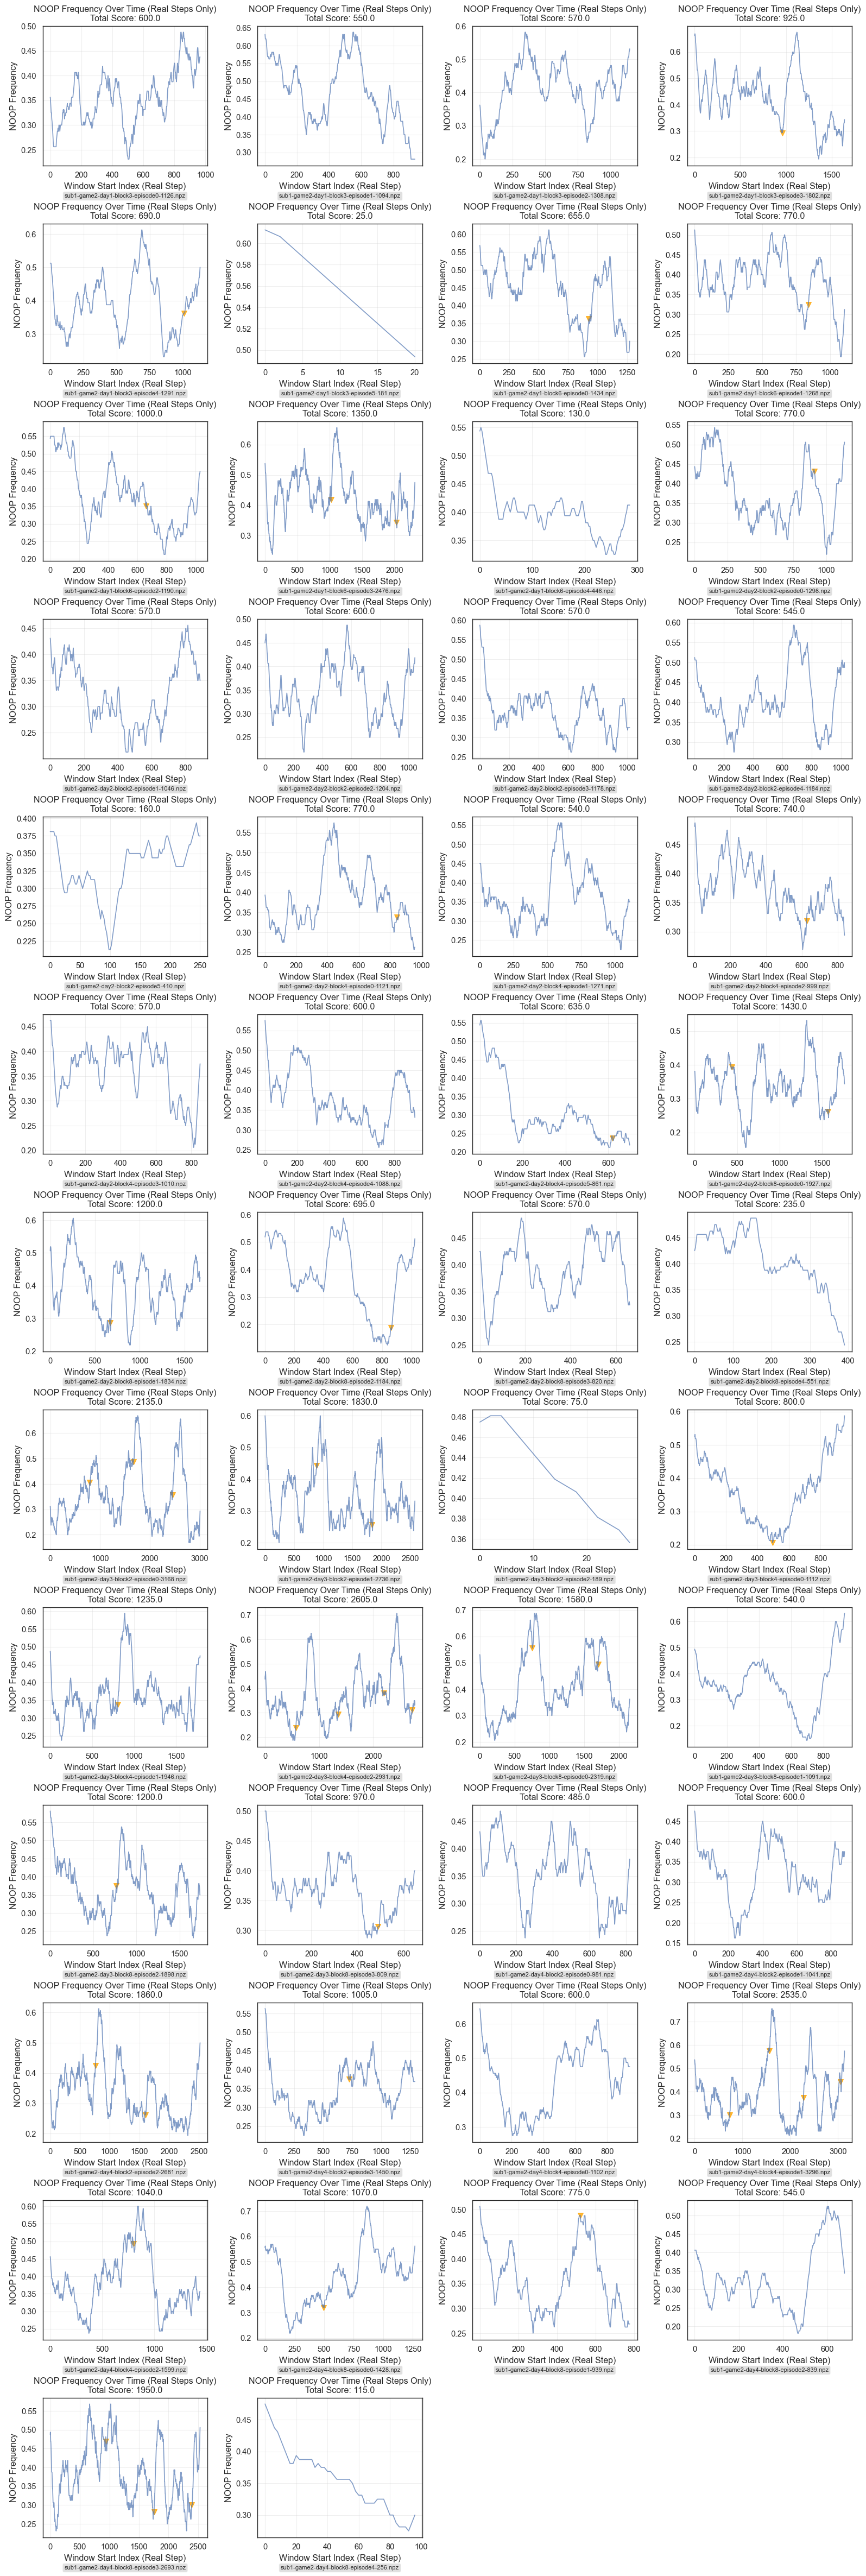

전체 파일들의 평균 NOOP frequency 그래프 생성 중...


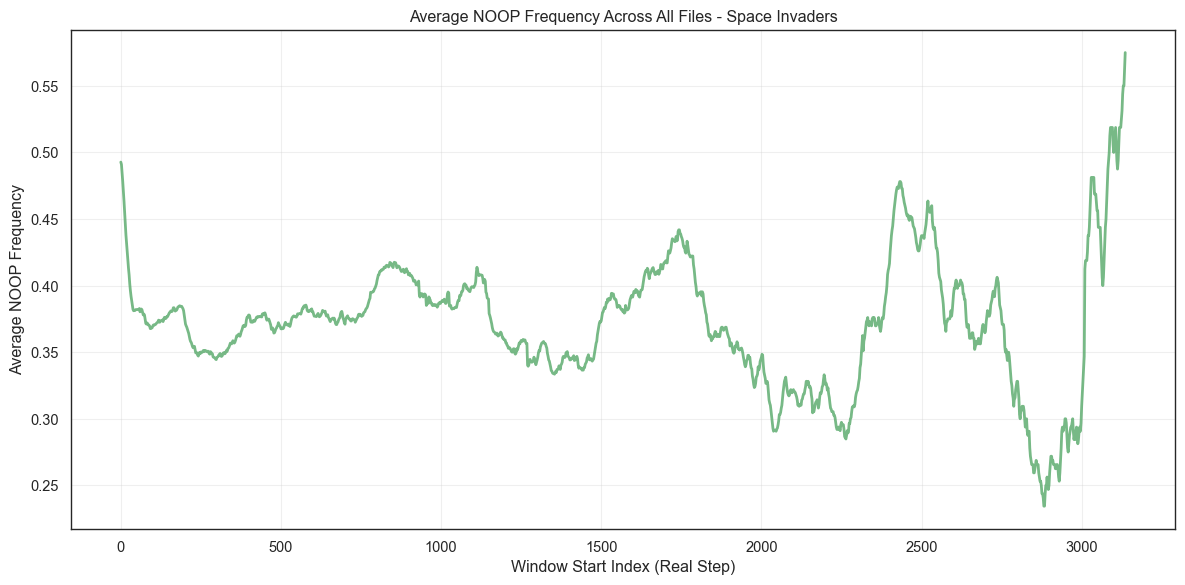

평균 그래프 완성: 1569개의 window 지점
전체 파일 수: 50개
총 데이터 포인트: 30593개


In [19]:
analyze_noop_frequency2(
    subjects=[1],  # subject 1만 분석
    game_id=2,     # game_2 (Space Invaders)
    window_size=160,  # window 크기 100
    stride=2
)

In [ ]:
import numpy as np

data = np.load("E:/behav/behavioral_data_4kframe_legacy/sub_1/game_1/day_1/block_3/sub1-game2-day1-block3-episode0-1126.npz")

data['reward'][35:100]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 5, 0, 0, 0, 0, 0, 0],
      dtype=int64)